# Axe 3 — Bloc 1 : PCA / Factor Analysis
## AtlanticRe — Scoring Intelligent des Marchés d'Assurance Africains 2030

> **Objectif** : Laisser les données révéler les poids au lieu de les imposer manuellement.  
> **Input** : `predictions_2025_2030_AtlanticRe.csv` (filtré 2030)  
> **Output** : `scoring_pca_2030_AtlanticRe.csv` + 4 visualisations PNG  
> **Prérequis** : Axe 2 (prédictions) + Bloc 3 (Monte Carlo) terminés

---

## 0. Setup & Chargement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Seed global — garantit la reproductibilité de la PCA
RANDOM_SEED = 42

# ── Couleurs régionales standard du projet ──────────────────────────────────
REGION_COLORS = {
    'Afrique du Nord'    : '#e63946',
    "Afrique de l'Ouest" : '#2a9d8f',
    'Afrique Centrale'   : '#e9c46a',
    "Afrique de l'Est"   : '#457b9d',
    'Afrique Australe'   : '#8338ec',
}

# ── Régions ─────────────────────────────────────────────────────────────────
REGIONS = {
    'Afrique du Nord'    : ['Algérie', 'Égypte', 'Maroc', 'Tunisie'],
    "Afrique de l'Ouest" : ['Bénin', 'Burkina Faso', 'Cap-Vert', "Côte d'Ivoire",
                            'Ghana', 'Mali', 'Mauritanie', 'Niger', 'Nigeria',
                            'Sénégal', 'Togo'],
    'Afrique Centrale'   : ['Cameroun', 'Congo', 'Gabon', 'RDC', 'Tchad'],
    "Afrique de l'Est"   : ['Burundi', 'Éthiopie', 'Kenya', 'Madagascar',
                            'Mozambique', 'Ouganda', 'Tanzanie'],
    'Afrique Australe'   : ['Angola', 'Botswana', 'Malawi', 'Maurice',
                            'Namibie', 'Zambie'],
}
pays_to_region = {p: r for r, pays in REGIONS.items() for p in pays}

# ── Chargement des données ───────────────────────────────────────────────────
df_pred = pd.read_csv('predictions_2025_2030_AtlanticRe.csv')
assert not df_pred.empty, "Le fichier CSV chargé est vide — vérifier le chemin"

df_mc   = pd.read_csv('scoring_mc_2030_AtlanticRe.csv')      # Bloc 3 — référence
assert not df_mc.empty, "Le fichier CSV chargé est vide — vérifier le chemin"

df_axe2 = pd.read_csv('score_attractivite_2030_AtlanticRe.csv')  # Axe 2 — référence
assert not df_axe2.empty, "Le fichier CSV chargé est vide — vérifier le chemin"

# ── Filtrer sur 2030 uniquement ──────────────────────────────────────────────
df_2030 = df_pred[df_pred['Year'] == 2030].copy().reset_index(drop=True)
assert df_2030['Pays'].nunique() == 33, f"ERREUR : {df_2030['Pays'].nunique()} pays (attendu 33)"
print(f"✅ {len(df_2030)} lignes chargées — {df_2030['Pays'].nunique()} pays — année 2030")

✅ 33 lignes chargées — 33 pays — année 2030


## 1. Paramétrage

In [2]:
# ── Variables d'entrée PCA ───────────────────────────────────────────────────
VARS_PCA = [
    'nv_penetration_pred',   # taille marché NV
    'vie_penetration_pred',  # taille marché Vie
    'nv_sp_inv',             # S/P inversé : ratio bas = bon marché (voir création ci-dessous)
    'gdpcap_pred',           # richesse individuelle
    'polstab_pred',          # stabilité opérationnelle
    'regqual_pred',          # cadre réglementaire
    'nv_primes_pred',        # volume de marché absolu NV
    'nv_densite_pred',       # densité assurance NV
]

# Labels lisibles pour les visualisations
VAR_LABELS = {
    'nv_penetration_pred'  : 'NV Pénétration (%)',
    'vie_penetration_pred' : 'Vie Pénétration (%)',
    'nv_sp_inv'            : 'Ratio S/P inversé (−)',
    'gdpcap_pred'          : 'PIB/hab (USD)',
    'polstab_pred'         : 'Stabilité Politique',
    'regqual_pred'         : 'Qualité Régl.',
    'nv_primes_pred'       : 'NV Primes (M USD)',
    'nv_densite_pred'      : 'NV Densité (USD/hab)',
}
LABELS = [VAR_LABELS[v] for v in VARS_PCA]

# S/P inversé AVANT la PCA : un ratio S/P élevé = marché moins attractif.
# En inversant ici (-nv_sp_pred), un loading positif sur nv_sp_inv signifie
# toujours « bonne attractivité » — cohérent avec les autres variables.
# L'inversion est donc structurelle et non laissée à l'interprétation.
VAR_INVERTED = {'nv_sp_inv'}   # inversion appliquée en amont (dans la cellule Standardisation)

# Poids Axe 2 (référence pour comparaison)
WEIGHTS_AXE2 = {
    'nv_penetration_pred'  : 0.30,
    'nv_sp_inv'            : 0.25,   # anciennement nv_sp_pred — même poids, variable inversée
    'gdpcap_pred'          : 0.20,
    'polstab_pred'         : 0.12,
    'regqual_pred'         : 0.08,
    'vie_penetration_pred' : 0.05,
    'nv_primes_pred'       : 0.00,
    'nv_densite_pred'      : 0.00,
}

print("Variables PCA :", VARS_PCA)
print(f"Matrice d'entrée : 33 pays × {len(VARS_PCA)} variables")


Variables PCA : ['nv_penetration_pred', 'vie_penetration_pred', 'nv_sp_pred', 'gdpcap_pred', 'polstab_pred', 'regqual_pred', 'nv_primes_pred', 'nv_densite_pred']
Matrice d'entrée : 33 pays × 8 variables


## 2. Standardisation Z-score

In [3]:
# ── Inversion de nv_sp_pred AVANT la standardisation ────────────────────────
# S/P inversé : un ratio S/P élevé = marché moins attractif.
# En négativant la variable, un loading positif sur nv_sp_inv
# signifie systématiquement 'bonne attractivité' — cohérent avec toutes les autres variables.
df_2030['nv_sp_inv'] = -df_2030['nv_sp_pred']

X = df_2030[VARS_PCA].values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("Statistiques après standardisation (doit être ≈ μ=0, σ=1 par colonne) :")
df_std_stats = pd.DataFrame(
    {'Moyenne': X_std.mean(axis=0).round(4),
     'Écart-type': X_std.std(axis=0).round(4)},
    index=LABELS
)
print(df_std_stats)

Statistiques après standardisation (doit être ≈ μ=0, σ=1 par colonne) :
                      Moyenne  Écart-type
NV Pénétration (%)       -0.0         1.0
Vie Pénétration (%)       0.0         1.0
Ratio S/P (%)             0.0         1.0
PIB/hab (USD)            -0.0         1.0
Stabilité Politique       0.0         1.0
Qualité Régl.             0.0         1.0
NV Primes (M USD)        -0.0         1.0
NV Densité (USD/hab)      0.0         1.0


## 3. PCA complète — Scree plot & sélection du nombre de composantes

In [4]:
# PCA complète (toutes les composantes)
pca_full = PCA()
pca_full.fit(X_std)

eigenvalues = pca_full.explained_variance_
var_ratio   = pca_full.explained_variance_ratio_
var_cumul   = np.cumsum(var_ratio)

print("Eigenvalues par composante :")
df_scree = pd.DataFrame({
    'Eigenvalue'         : eigenvalues.round(3),
    'Variance expliquée' : (var_ratio * 100).round(1),
    'Cumulée (%)'        : (var_cumul * 100).round(1),
    'Kaiser (>1)'        : ['✅' if e > 1 else '❌' for e in eigenvalues],
}, index=[f'PC{i+1}' for i in range(len(eigenvalues))])
print(df_scree.to_string())

# Critère Kaiser : eigenvalue > 1
n_kaiser = (eigenvalues > 1).sum()
# Critère 80% variance cumulée
n_80pct  = int(np.argmax(var_cumul >= 0.80)) + 1

print(f"\n→ Critère Kaiser (eigenvalue > 1)     : {n_kaiser} composantes")
print(f"→ Critère 80% variance cumulée         : {n_80pct} composantes")

# Décision : on prend le max des deux critères pour maximiser l'information
N_COMP = max(n_kaiser, n_80pct)
print(f"\n✅ Décision finale : N_COMP = {N_COMP} composantes retenues")
print(f"   Variance expliquée cumulée : {var_cumul[N_COMP-1]*100:.1f}%")

Eigenvalues par composante :
     Eigenvalue  Variance expliquée  Cumulée (%) Kaiser (>1)
PC1       4.485                54.4         54.4           ✅
PC2       1.466                17.8         72.1           ✅
PC3       0.890                10.8         82.9           ❌
PC4       0.574                 7.0         89.9           ❌
PC5       0.420                 5.1         95.0           ❌
PC6       0.249                 3.0         98.0           ❌
PC7       0.130                 1.6         99.6           ❌
PC8       0.035                 0.4        100.0           ❌

→ Critère Kaiser (eigenvalue > 1)     : 2 composantes
→ Critère 80% variance cumulée         : 3 composantes

✅ Décision finale : N_COMP = 3 composantes retenues
   Variance expliquée cumulée : 82.9%


## 4. Rotation Varimax — Loadings interprétables

In [5]:
def varimax(Phi, gamma=1.0, q=200, tol=1e-8):
    """Rotation Varimax manuelle — maximise la variance des loadings au carré."""
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma / p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        )
        R = u @ vh
        d = np.sum(s)
        if d_old != 0 and d / d_old < 1 + tol:
            break
    return Phi @ R

# PCA avec N_COMP composantes
pca = PCA(n_components=N_COMP)
scores_pca_raw = pca.fit_transform(X_std)

# Loadings bruts PCA : components_.T × √eigenvalues
loadings_raw = pca.components_.T * np.sqrt(pca.explained_variance_)

# Rotation Varimax
loadings_varimax = varimax(loadings_raw)

# ── Tableau des loadings ─────────────────────────────────────────────────────
col_names = [f'F{i+1}' for i in range(N_COMP)]
df_loadings = pd.DataFrame(loadings_varimax, index=LABELS, columns=col_names)

print("Loadings après rotation Varimax (|loading| > 0.50 = contribution forte) :")
print(df_loadings.round(3).to_string())

# ── Variance expliquée par facteur (sum of squared loadings) ─────────────────
SS_loadings = np.sum(loadings_varimax**2, axis=0)
SS_total    = np.sum(SS_loadings)
var_by_factor = SS_loadings / len(VARS_PCA)  # proportion de variance totale
weights_pca   = SS_loadings / SS_total        # poids pour score composite

print("\nVariance expliquée par facteur (sum of squared loadings) :")
for i, (ss, vf, w) in enumerate(zip(SS_loadings, var_by_factor, weights_pca)):
    print(f"  F{i+1} : SS={ss:.3f}  |  {vf*100:.1f}% variance  |  poids score = {w:.3f}")

Loadings après rotation Varimax (|loading| > 0.50 = contribution forte) :
                         F1     F2     F3
NV Pénétration (%)    0.565  0.256  0.716
Vie Pénétration (%)   0.280 -0.017  0.923
Ratio S/P (%)         0.186  0.903 -0.113
PIB/hab (USD)         0.932  0.145  0.137
Stabilité Politique   0.787 -0.194  0.320
Qualité Régl.         0.856  0.070  0.295
NV Primes (M USD)    -0.032  0.780  0.391
NV Densité (USD/hab)  0.875  0.196  0.302

Variance expliquée par facteur (sum of squared loadings) :
  F1 : SS=3.419  |  42.7% variance  |  poids score = 0.500
  F2 : SS=1.592  |  19.9% variance  |  poids score = 0.233
  F3 : SS=1.830  |  22.9% variance  |  poids score = 0.267


## 5. Interprétation des facteurs

In [6]:
# Nommage des facteurs (basé sur les loadings dominants)
FACTOR_NAMES = []
for i in range(N_COMP):
    col = df_loadings[f'F{i+1}']
    dominant = col.abs().sort_values(ascending=False).head(3)
    print(f"\nF{i+1} — Variables dominantes (loading > 0.50 en valeur absolue) :")
    for var, val in dominant.items():
        flag = '★' if abs(val) >= 0.50 else ' '
        print(f"  {flag} {var:30s} : {val:+.3f}")

# Noms attribués (à ajuster selon les loadings observés)
FACTOR_NAMES = {
    'F1': 'Richesse & Gouvernance',
    'F2': 'Rentabilité & Volume',
    'F3': 'Pénétration Assurance',
}
print("\n" + "="*60)
print("NOMMAGE DES FACTEURS :")
for k, v in FACTOR_NAMES.items():
    print(f"  {k} → {v}")


F1 — Variables dominantes (loading > 0.50 en valeur absolue) :
  ★ PIB/hab (USD)                  : +0.932
  ★ NV Densité (USD/hab)           : +0.875
  ★ Qualité Régl.                  : +0.856

F2 — Variables dominantes (loading > 0.50 en valeur absolue) :
  ★ Ratio S/P (%)                  : +0.903
  ★ NV Primes (M USD)              : +0.780
    NV Pénétration (%)             : +0.256

F3 — Variables dominantes (loading > 0.50 en valeur absolue) :
  ★ Vie Pénétration (%)            : +0.923
  ★ NV Pénétration (%)             : +0.716
    NV Primes (M USD)              : +0.391

NOMMAGE DES FACTEURS :
  F1 → Richesse & Gouvernance
  F2 → Rentabilité & Volume
  F3 → Pénétration Assurance


## 6. Scores factoriels & Score composite PCA

In [7]:
# Scores factoriels par projection dans l'espace Varimax
# score_factoriel = X_std @ L @ (L^T L)^-1
L = loadings_varimax
scores_varimax = X_std @ L @ np.linalg.inv(L.T @ L)


# S/P déjà inversé en amont (nv_sp_inv = -nv_sp_pred) — aucune correction à appliquer ici
# Score composite = somme pondérée des scores factoriels
# Pondération : variance expliquée par facteur (SS_loadings normalisé)
score_composite_raw = scores_varimax @ weights_pca

# Normalisation min-max → [0, 100]
sc_min = score_composite_raw.min()
sc_max = score_composite_raw.max()
score_pca_100 = 100 * (score_composite_raw - sc_min) / (sc_max - sc_min)

# Assemblage DataFrame résultat
df_result = df_2030[['Pays', 'Region']].copy()
for i in range(N_COMP):
    df_result[f'score_F{i+1}'] = scores_varimax[:, i].round(4)
df_result['score_composite_pca'] = score_composite_raw.round(4)
df_result['score_pca_100']       = score_pca_100.round(2)

# Classement
df_result = df_result.sort_values('score_pca_100', ascending=False).reset_index(drop=True)
df_result['rang_pca'] = range(1, 34)

# Merge avec rang MC (référence Bloc 3)
df_result = df_result.merge(
    df_mc[['Pays', 'rang_P50', 'score_P50', 'borda_score']],
    on='Pays', how='left'
)
df_result['delta_rang'] = df_result['rang_pca'] - df_result['rang_P50']

print("Top 15 — Scoring PCA 2030 :")
print(df_result[['rang_pca','Pays','Region','score_pca_100','rang_P50','delta_rang']]
      .head(15).to_string(index=False))
print("\nBottom 5 :")
print(df_result[['rang_pca','Pays','Region','score_pca_100','rang_P50','delta_rang']]
      .tail(5).to_string(index=False))

Top 15 — Scoring PCA 2030 :
 rang_pca          Pays             Region  score_pca_100  rang_P50  delta_rang
        1       Maurice   Afrique Australe         100.00         2          -1
        2         Maroc    Afrique du Nord          71.71         5          -3
        3       Namibie   Afrique Australe          52.56         1           2
        4      Cap-Vert Afrique de l'Ouest          47.51         3           1
        5      Botswana   Afrique Australe          46.65         4           1
        6       Tunisie    Afrique du Nord          46.60         7          -1
        7         Kenya   Afrique de l'Est          41.18        21         -14
        8       Algérie    Afrique du Nord          36.76        12          -4
        9         Gabon   Afrique Centrale          30.09         9           0
       10 Côte d'Ivoire Afrique de l'Ouest          30.07        15          -5
       11         Ghana Afrique de l'Ouest          26.57        11           0
       12   

## 7. Comparaison poids PCA vs poids Axe 2

In [8]:
# Poids implicites PCA : contribution de chaque variable au score composite
# via la chaîne : score_composite = X_std @ L @ (L^T L)^-1 @ weights_pca
# Contribution brute par variable = coefficients dans cette chaîne
coeff_chain = L @ np.linalg.inv(L.T @ L) @ weights_pca
poids_pca_implicit = np.abs(coeff_chain) / np.abs(coeff_chain).sum()  # normalisés

df_weights = pd.DataFrame({
    'Variable'    : LABELS,
    'Poids Axe 2' : [WEIGHTS_AXE2.get(v, 0.0) for v in VARS_PCA],
    'Poids PCA'   : poids_pca_implicit.round(3),
})
df_weights['Diff (PCA - Axe2)'] = (df_weights['Poids PCA'] - df_weights['Poids Axe 2']).round(3)

print("Comparaison poids Axe 2 (manuels) vs poids PCA (appris par les données) :")
print(df_weights.sort_values('Poids PCA', ascending=False).to_string(index=False))

Comparaison poids Axe 2 (manuels) vs poids PCA (appris par les données) :
            Variable  Poids Axe 2  Poids PCA  Diff (PCA - Axe2)
NV Densité (USD/hab)         0.00      0.161              0.161
       PIB/hab (USD)         0.20      0.159             -0.041
       Qualité Régl.         0.08      0.142              0.062
       Ratio S/P (%)         0.25      0.137             -0.113
  NV Pénétration (%)         0.30      0.134             -0.166
   NV Primes (M USD)         0.00      0.103              0.103
 Stabilité Politique         0.12      0.100             -0.020
 Vie Pénétration (%)         0.05      0.064              0.014


## 8. Export CSV

In [9]:
# ── Préparation du CSV final ─────────────────────────────────────────────────
# Ajouter les loadings et poids comme métadonnées dans le CSV
# CSV principal : scoring par pays
cols_export = ['Pays', 'Region', 'rang_pca', 'score_pca_100'] + \
              [f'score_F{i+1}' for i in range(N_COMP)] + \
              ['rang_P50', 'delta_rang']

df_export = df_result[cols_export].copy()
df_export.to_csv('scoring_pca_2030_AtlanticRe.csv', index=False)
print(f"✅ scoring_pca_2030_AtlanticRe.csv exporté ({len(df_export)} lignes, {len(df_export.columns)} colonnes)")
print(f"   Colonnes : {list(df_export.columns)}")

# CSV secondaire : loadings (pour réutilisation Bloc 4 TOPSIS)
df_loadings_export = df_loadings.copy()
df_loadings_export['Variable'] = VARS_PCA
df_loadings_export['poids_pca_implicit'] = poids_pca_implicit.round(4)
df_loadings_export.to_csv('pca_loadings_2030_AtlanticRe.csv', index=True)
print(f"✅ pca_loadings_2030_AtlanticRe.csv exporté (loadings Varimax + poids implicites)")

✅ scoring_pca_2030_AtlanticRe.csv exporté (33 lignes, 9 colonnes)
   Colonnes : ['Pays', 'Region', 'rang_pca', 'score_pca_100', 'score_F1', 'score_F2', 'score_F3', 'rang_P50', 'delta_rang']
✅ pca_loadings_2030_AtlanticRe.csv exporté (loadings Varimax + poids implicites)


## 9. Visualisations

### 9.1 Scree Plot — Variance expliquée

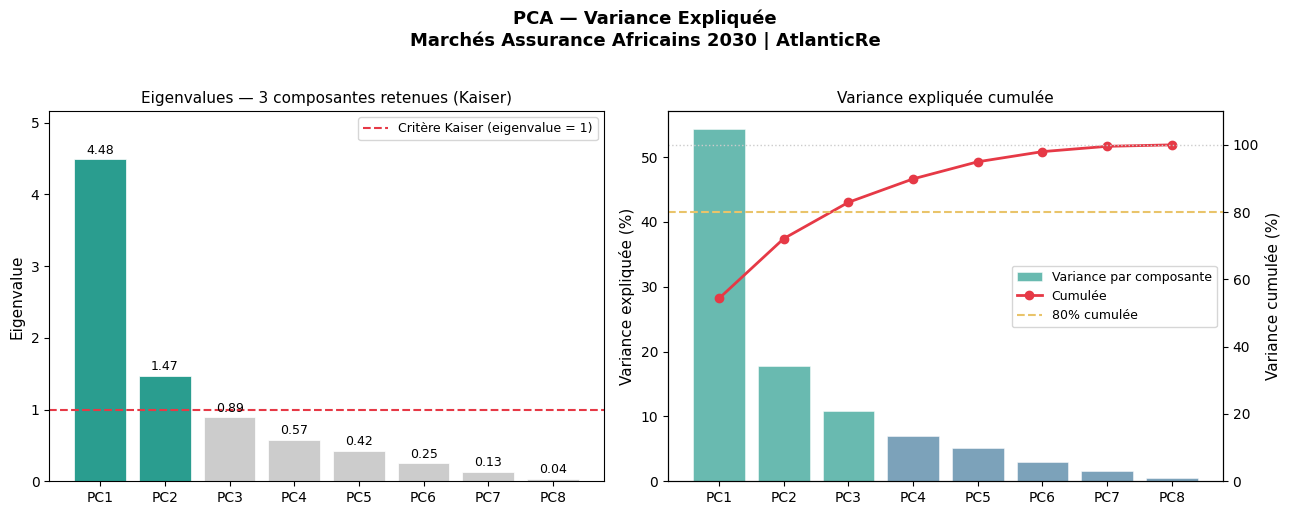

✅ pca_variance_expliquee.png sauvegardé


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PCA — Variance Expliquée\nMarchés Assurance Africains 2030 | AtlanticRe',
             fontsize=13, fontweight='bold', y=1.02)

comps = [f'PC{i+1}' for i in range(len(eigenvalues))]

# Gauche : eigenvalues + ligne Kaiser
ax = axes[0]
bars = ax.bar(comps, eigenvalues, color=['#2a9d8f' if e > 1 else '#ccc' for e in eigenvalues],
              edgecolor='white', linewidth=0.5)
ax.axhline(1.0, color='#e63946', ls='--', lw=1.5, label='Critère Kaiser (eigenvalue = 1)')
ax.set_ylabel('Eigenvalue', fontsize=11)
ax.set_title('Eigenvalues par composante', fontsize=11)
ax.legend(fontsize=9)
for bar, val in zip(bars, eigenvalues):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, eigenvalues.max() * 1.15)

# Droite : variance cumulée
ax = axes[1]
ax.bar(comps, var_ratio * 100, color='#457b9d', alpha=0.7,
       edgecolor='white', linewidth=0.5, label='Variance par composante')
ax2 = ax.twinx()
ax2.plot(comps, var_cumul * 100, 'o-', color='#e63946', lw=2, ms=6, label='Cumulée')
ax2.axhline(80, color='#e9c46a', ls='--', lw=1.5, label='80% cumulée')
ax2.axhline(100, color='#ccc', ls=':', lw=1)
ax2.set_ylabel('Variance cumulée (%)', fontsize=11)
ax2.set_ylim(0, 110)
ax.set_ylabel('Variance expliquée (%)', fontsize=11)
ax.set_title('Variance expliquée cumulée', fontsize=11)

# Zone retenue
for i in range(N_COMP):
    axes[0].get_children()[i].set_alpha(1.0)
    axes[1].patches[i].set_facecolor('#2a9d8f')

# Légende combinée
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=9, loc='center right')

# Annotation zone retenue
axes[0].set_title(f'Eigenvalues — {N_COMP} composantes retenues (Kaiser)', fontsize=11)

plt.tight_layout()
plt.savefig('pca_variance_expliquee.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ pca_variance_expliquee.png sauvegardé")

### 9.2 Heatmap des loadings Varimax

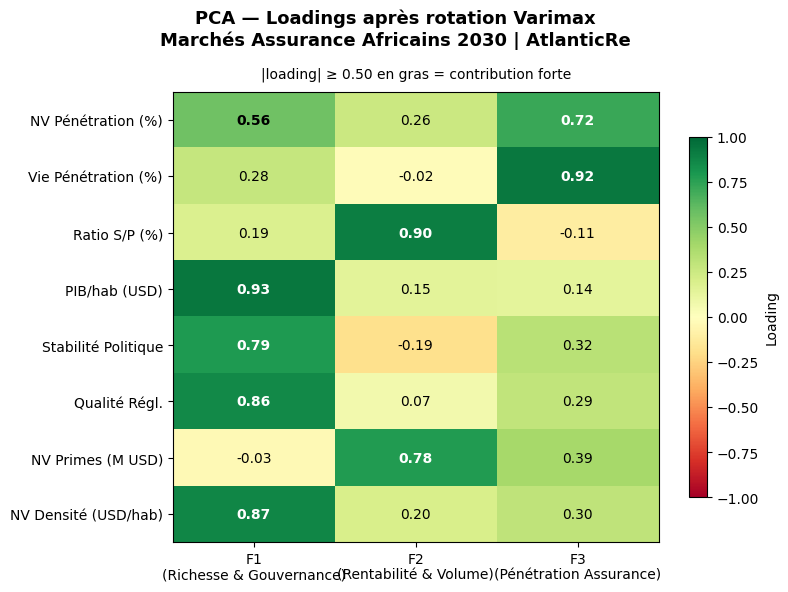

✅ pca_loadings.png sauvegardé


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('PCA — Loadings après rotation Varimax\nMarchés Assurance Africains 2030 | AtlanticRe',
             fontsize=13, fontweight='bold')

data_heatmap = df_loadings.values
im = ax.imshow(data_heatmap, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(N_COMP))
ax.set_xticklabels(
    [f'F{i+1}\n({FACTOR_NAMES.get(f"F{i+1}", f"Facteur {i+1}")})' for i in range(N_COMP)],
    fontsize=10
)
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS, fontsize=10)

# Annotations des valeurs
for i in range(len(LABELS)):
    for j in range(N_COMP):
        val = data_heatmap[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        weight = 'bold' if abs(val) >= 0.50 else 'normal'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color=color, fontsize=10, fontweight=weight)

# Barre de couleur
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Loading', fontsize=10)

# Légende
ax.set_title(f'|loading| ≥ 0.50 en gras = contribution forte', fontsize=10, pad=10)

plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ pca_loadings.png sauvegardé")

### 9.3 Biplot — Pays + Variables dans l'espace F1×F2

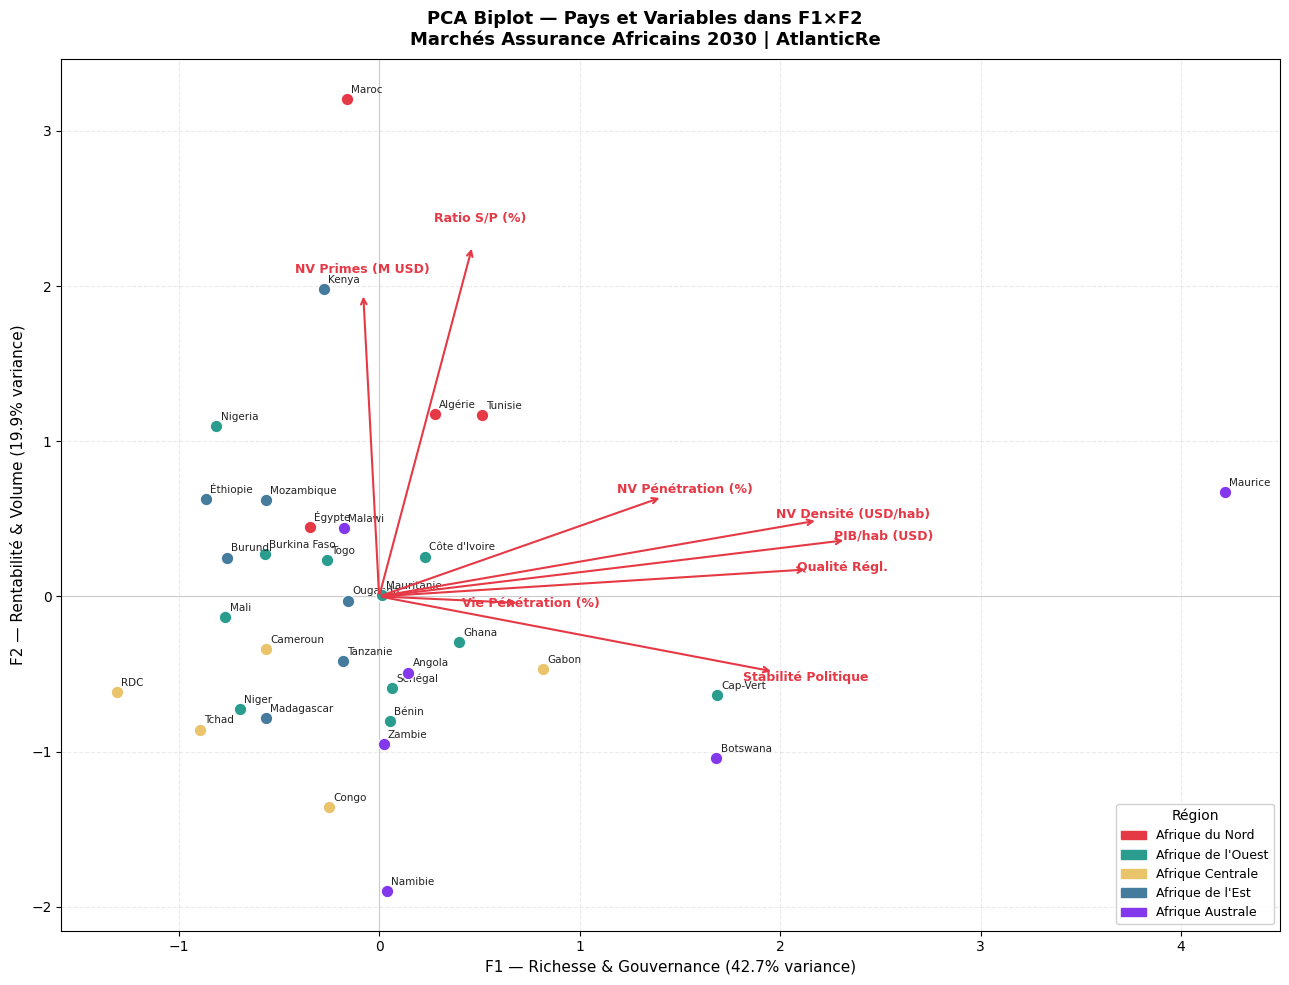

✅ pca_biplot.png sauvegardé


In [12]:
fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('PCA Biplot — Pays et Variables dans F1×F2\nMarchés Assurance Africains 2030 | AtlanticRe',
             fontsize=13, fontweight='bold')

# ── Scatter des pays ─────────────────────────────────────────────────────────
for _, row in df_result.iterrows():
    pays = row['Pays']
    region = row['Region']
    color = REGION_COLORS.get(region, '#999')
    idx_pays = df_2030[df_2030['Pays'] == pays].index[0]
    x = scores_varimax[idx_pays, 0]
    y = scores_varimax[idx_pays, 1]
    ax.scatter(x, y, color=color, s=80, zorder=3, edgecolors='white', lw=0.8)
    ax.annotate(pays, (x, y), fontsize=7.5, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points', color='#222')

# ── Flèches des variables ────────────────────────────────────────────────────
scale = 2.5  # facteur d'échelle pour les flèches
for i, label in enumerate(LABELS):
    lx = loadings_varimax[i, 0]
    ly = loadings_varimax[i, 1]
    ax.annotate('', xy=(lx * scale, ly * scale), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#e63946', lw=1.5))
    ax.text(lx * scale * 1.08, ly * scale * 1.08, label,
            color='#e63946', fontsize=9, fontweight='bold', ha='center', va='center')

# ── Axes et légende ──────────────────────────────────────────────────────────
ax.axhline(0, color='#ccc', lw=0.8, ls='-')
ax.axvline(0, color='#ccc', lw=0.8, ls='-')
ax.set_xlabel(f'F1 — {FACTOR_NAMES.get("F1", "Facteur 1")} ({var_by_factor[0]*100:.1f}% variance)',
              fontsize=11)
ax.set_ylabel(f'F2 — {FACTOR_NAMES.get("F2", "Facteur 2")} ({var_by_factor[1]*100:.1f}% variance)',
              fontsize=11)

legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=legend_patches, title='Région', fontsize=9, title_fontsize=10,
          loc='lower right', framealpha=0.9)

ax.grid(True, alpha=0.25, ls='--')
plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ pca_biplot.png sauvegardé")

### 9.4 Comparaison poids PCA vs poids Axe 2 + Classement final

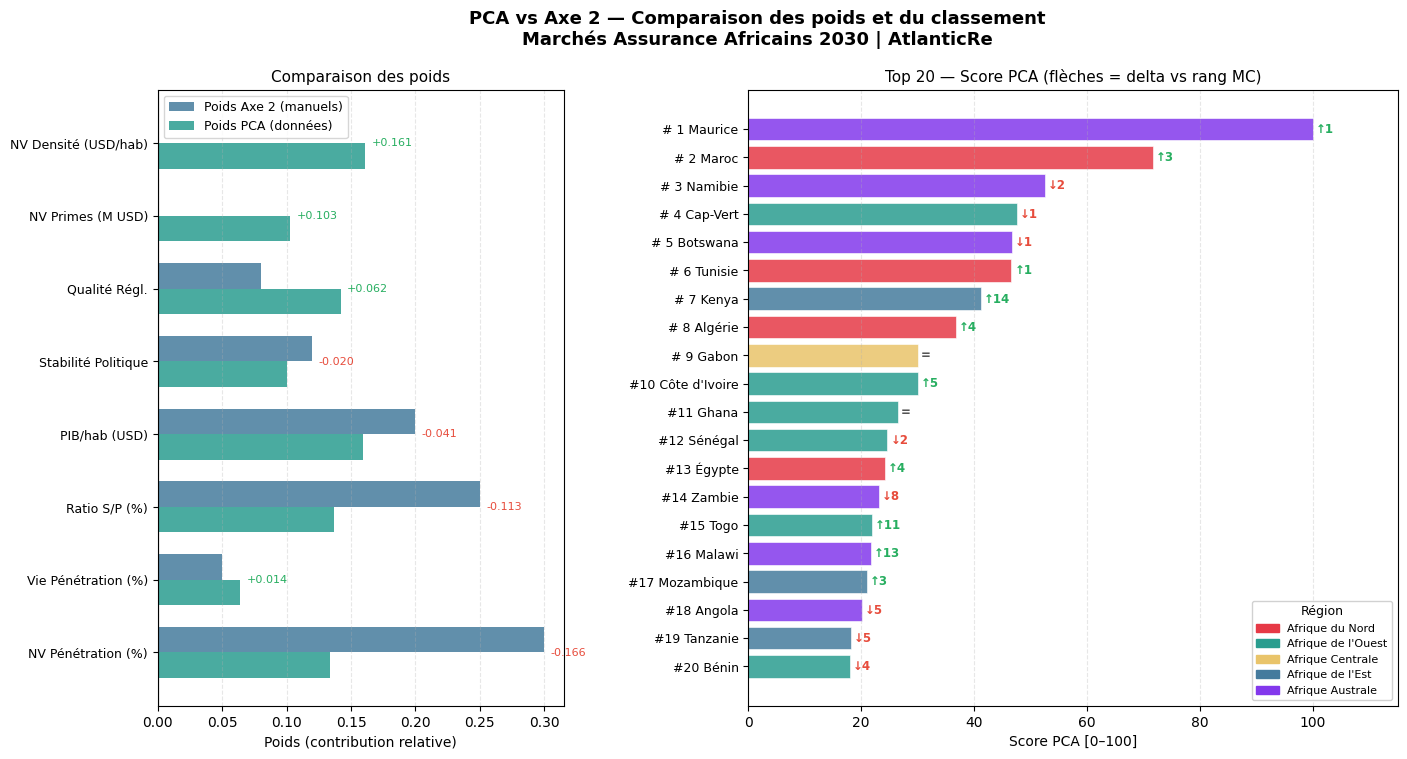

✅ pca_vs_axe2_comparison.png sauvegardé


In [13]:
fig = plt.figure(figsize=(16, 8))
fig.suptitle('PCA vs Axe 2 — Comparaison des poids et du classement\nMarchés Assurance Africains 2030 | AtlanticRe',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.6], wspace=0.35)

# ── Gauche : barplot poids comparés ─────────────────────────────────────────
ax_w = fig.add_subplot(gs[0])
y_pos = np.arange(len(LABELS))
w = 0.35
bars1 = ax_w.barh(y_pos + w/2, df_weights['Poids Axe 2'], w,
                  color='#457b9d', alpha=0.85, label='Poids Axe 2 (manuels)')
bars2 = ax_w.barh(y_pos - w/2, df_weights['Poids PCA'], w,
                  color='#2a9d8f', alpha=0.85, label='Poids PCA (données)')

ax_w.set_yticks(y_pos)
ax_w.set_yticklabels(LABELS, fontsize=9)
ax_w.set_xlabel('Poids (contribution relative)', fontsize=10)
ax_w.set_title('Comparaison des poids', fontsize=11)
ax_w.legend(fontsize=9)
ax_w.axvline(0, color='#333', lw=0.8)
ax_w.grid(axis='x', alpha=0.3, ls='--')

# Annotations diff
for i, (_, row) in enumerate(df_weights.iterrows()):
    diff = row['Diff (PCA - Axe2)']
    color = '#27ae60' if diff > 0 else '#e74c3c'
    ax_w.text(max(row['Poids PCA'], row['Poids Axe 2']) + 0.005, i,
              f'{diff:+.3f}', va='center', fontsize=8, color=color)

# ── Droite : classement PCA vs Monte Carlo ───────────────────────────────────
ax_r = fig.add_subplot(gs[1])
df_plot = df_result.head(20).sort_values('score_pca_100', ascending=True)

colors = [REGION_COLORS.get(r, '#999') for r in df_plot['Region']]
bars = ax_r.barh(range(len(df_plot)), df_plot['score_pca_100'],
                 color=colors, alpha=0.85, edgecolor='white', lw=0.5)

# Rang MC en overlay
for j, (_, row) in enumerate(df_plot.iterrows()):
    delta = int(row['delta_rang'])
    symbol = '↑' if delta < 0 else ('↓' if delta > 0 else '=')
    color_d = '#27ae60' if delta < 0 else ('#e74c3c' if delta > 0 else '#555')
    ax_r.text(row['score_pca_100'] + 0.5, j,
              f'{symbol}{abs(delta) if delta != 0 else ""}',
              va='center', fontsize=8.5, color=color_d, fontweight='bold')

ax_r.set_yticks(range(len(df_plot)))
ax_r.set_yticklabels(
    [f"#{int(r.rang_pca):>2} {r.Pays}" for _, r in df_plot.iterrows()],
    fontsize=9
)
ax_r.set_xlabel('Score PCA [0–100]', fontsize=10)
ax_r.set_title('Top 20 — Score PCA (flèches = delta vs rang MC)', fontsize=11)
ax_r.set_xlim(0, 115)
ax_r.grid(axis='x', alpha=0.3, ls='--')

# Légende régions
legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax_r.legend(handles=legend_patches, title='Région', fontsize=8, title_fontsize=9,
            loc='lower right', framealpha=0.9)

plt.savefig('pca_vs_axe2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ pca_vs_axe2_comparison.png sauvegardé")

## 10. Synthèse & Interprétation

In [14]:
print("=" * 70)
print("TABLEAU DE BORD FINAL — BLOC 1 PCA / FACTOR ANALYSIS")
print("AtlanticRe — Scoring Marchés Africains 2030")
print("=" * 70)

print(f"""
PARAMÈTRES PCA
  Variables d'entrée     : {len(VARS_PCA)} variables (prédictions 2030)
  Pays                   : 33
  Composantes retenues   : {N_COMP} (critère Kaiser + 80% variance)
  Variance cumulée       : {var_cumul[N_COMP-1]*100:.1f}%
  Rotation               : Varimax (orthogonale)

FACTEURS IDENTIFIÉS
""")
for i in range(N_COMP):
    fname = FACTOR_NAMES.get(f'F{i+1}', f'Facteur {i+1}')
    print(f"  F{i+1} — {fname:30s} | Variance: {var_by_factor[i]*100:.1f}% | Poids: {weights_pca[i]:.3f}")
    # Variables dominantes
    col = df_loadings[f'F{i+1}']
    dom = col.abs().sort_values(ascending=False).head(3)
    for var, val in dom.items():
        print(f"     → {var:28s} {val:+.3f}")
    print()

print("TOP 15 PAYS (Score PCA 2030)")
print("-" * 60)
for _, row in df_result.head(15).iterrows():
    delta = int(row['delta_rang'])
    symbol = f'↑{abs(delta)}' if delta < 0 else (f'↓{abs(delta)}' if delta > 0 else '=')
    print(f"  #{int(row['rang_pca']):>2}  {row['Pays']:<20} Score={row['score_pca_100']:>6.1f}  "
          f"Région={row['Region']:<22} vs MC: {symbol}")

print()
print("FICHIERS EXPORTÉS")
print("  ✅ scoring_pca_2030_AtlanticRe.csv  — classement PCA 33 pays")
print("  ✅ pca_loadings_2030_AtlanticRe.csv — loadings Varimax (input Bloc 4 TOPSIS)")
print("  ✅ pca_variance_expliquee.png")
print("  ✅ pca_loadings.png")
print("  ✅ pca_biplot.png")
print("  ✅ pca_vs_axe2_comparison.png")

print()
print("▶ Prochaine étape : Bloc 2 — Clustering non-supervisé")
print("  Notebook : axe3_atlanticre_scoring_bloc2_clustering.ipynb")
print("  Inputs   : predictions_2025_2030_AtlanticRe.csv")
print("             scoring_mc_2030_AtlanticRe.csv")
print("             scoring_pca_2030_AtlanticRe.csv")
print("=" * 70)

TABLEAU DE BORD FINAL — BLOC 1 PCA / FACTOR ANALYSIS
AtlanticRe — Scoring Marchés Africains 2030

PARAMÈTRES PCA
  Variables d'entrée     : 8 variables (prédictions 2030)
  Pays                   : 33
  Composantes retenues   : 3 (critère Kaiser + 80% variance)
  Variance cumulée       : 82.9%
  Rotation               : Varimax (orthogonale)

FACTEURS IDENTIFIÉS

  F1 — Richesse & Gouvernance         | Variance: 42.7% | Poids: 0.500
     → PIB/hab (USD)                +0.932
     → NV Densité (USD/hab)         +0.875
     → Qualité Régl.                +0.856

  F2 — Rentabilité & Volume           | Variance: 19.9% | Poids: 0.233
     → Ratio S/P (%)                +0.903
     → NV Primes (M USD)            +0.780
     → NV Pénétration (%)           +0.256

  F3 — Pénétration Assurance          | Variance: 22.9% | Poids: 0.267
     → Vie Pénétration (%)          +0.923
     → NV Pénétration (%)           +0.716
     → NV Primes (M USD)            +0.391

TOP 15 PAYS (Score PCA 2030)
--

## Synthèse PCA

Ce bloc applique une analyse en composantes principales (rotation Varimax) sur 8 variables prédites 2030 pour objectiver les poids du scoring. Les facteurs retenus (critère Kaiser + 80% de variance cumulée) alimentent les poids implicites transmis au Bloc 4 TOPSIS via `pca_loadings_2030_AtlanticRe.csv`.